# Detect Players in the Hull

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

from Plot import plot_cv, plot_img
from Cnn_Architecture import CourtDetection

In [2]:
model_path = "../Cnn_Architecture/court/keypoints_model.pth"
court_line = CourtDetection(model_path)

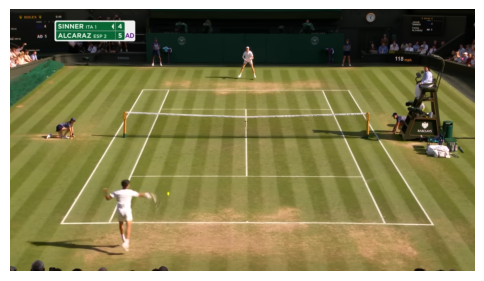

In [3]:
path = "../Data/tennis_game.png"
tennis = cv.imread(path, cv.IMREAD_COLOR_RGB)
plot_img(tennis)

In [4]:
pts = court_line.predict(tennis)
pts

array([     566.54,      324.31,      1374.2,      324.22,      214.76,      881.06,      1730.6,      879.34,      667.69,       324.3,      405.26,      880.82,        1273,      324.12,      1541.4,      879.46,      632.44,      401.75,      1309.1,      401.51,         503,      679.92,      1442.2,      679.17,
            970.23,      401.62,      972.58,      679.72], dtype=float32)

In [5]:
points = np.array(pts, dtype=np.float32).reshape(-1, 2)
Height, Width, channels = tennis.shape
black = np.zeros((Height, Width, channels), dtype=np.uint8)

## Refine Keypoints

In [6]:
def refine_keypoints_subpix(bgr_img, seeds, win_size = 10, zero_zone = (-1, -1), blur_ksize = 3):
    gray = cv.cvtColor(bgr_img, cv.COLOR_BGR2GRAY)
    if blur_ksize and blur_ksize > 1:
        gray = cv.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

    h, w = gray.shape

    #cornerSubPix
    win = (win_size, win_size)
    criteria = (cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_MAX_ITER, 40, 1e-3)

    refined = []
    ok_mask = []

    for (x, y) in seeds:
        #verify if the new window fits in the img
        rx = min(win_size, int(min(x, w - 1 - x)))
        ry = min(win_size, int(min(y, h - 1 - y)))
        if rx < 1 or ry < 1:
            refined.append([float(x), float(y)])
            ok_mask.append(False)
            continue

        local_win = (rx, ry)
        p = np.array([[[x, y]]], dtype=np.float32)  

        #for each point we calculate the window
        cv.cornerSubPix(gray, p, local_win, zero_zone, criteria)

        px, py = float(p[0, 0, 0]), float(p[0, 0, 1])
        if abs(px - x) <= win_size + 0.5 and abs(py - y) <= win_size + 0.5:
            refined.append([px, py])
            ok_mask.append(True)
        else:
            refined.append([float(x), float(y)])
            ok_mask.append(False)

    return np.array(refined, dtype=np.float32), np.array(ok_mask, dtype=bool)

In [7]:
refined, ok = refine_keypoints_subpix(tennis, points, win_size = 23)

In [8]:
hull = cv.convexHull(refined)
hull_int = hull.astype(int)  
cv.polylines(black, [hull_int], isClosed=True, color=(0, 0, 255), thickness=2)
cv.polylines(tennis, [hull_int], isClosed=True, color=(0, 0, 255), thickness=2)

array([[[ 34,  34,  30],
        [ 34,  34,  30],
        [ 34,  34,  30],
        ...,
        [  5,   8,   1],
        [  5,   8,   1],
        [  5,   8,   1]],

       [[ 34,  34,  30],
        [ 34,  34,  30],
        [ 34,  34,  30],
        ...,
        [  5,   8,   1],
        [  5,   8,   1],
        [  5,   8,   1]],

       [[ 34,  34,  30],
        [ 34,  34,  30],
        [ 34,  34,  30],
        ...,
        [  5,   8,   1],
        [  5,   8,   1],
        [  5,   8,   1]],

       ...,

       [[ 61,  38,  40],
        [ 62,  40,  41],
        [ 65,  43,  44],
        ...,
        [137, 134,  71],
        [137, 134,  71],
        [137, 134,  71]],

       [[ 61,  38,  41],
        [ 63,  40,  43],
        [ 66,  43,  46],
        ...,
        [138, 134,  72],
        [138, 135,  72],
        [138, 135,  72]],

       [[ 61,  38,  41],
        [ 63,  40,  43],
        [ 66,  43,  46],
        ...,
        [138, 135,  72],
        [139, 135,  72],
        [139, 135,  72]]

In [9]:
for (x, y) in refined:
    cv.circle(black, (int(x), int(y)), 8, (0, 255, 0), -1)
    cv.circle(tennis, (int(x), int(y)), 8, (0, 255, 0), -1)

## Detect Players

In [10]:
model = YOLO("yolo11n.pt")
out = model.predict(tennis, conf = 0.45)


0: 384x640 5 persons, 132.1ms
Speed: 5.0ms preprocess, 132.1ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


## Bouding Box Distance using the Feet

In [11]:
feet_img = tennis.copy()
for result in out:
    boxes = result.boxes  

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  
        conf = box.conf[0]  
        cls = int(box.cls[0])  

        cv.rectangle(feet_img, (x1, y1), (x2, y2), (0, 255, 0), 2)  
        label = f"Class {cls}, Conf: {conf:.2f}"
        cv.putText(feet_img, label, (x1, y1 - 10), cv.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255), 2)

        cx, cy = int((x1+x2) / 2), int(y2)
        player_point = (cx, cy)

        inside = cv.pointPolygonTest(hull, player_point, False)
        dist   = cv.pointPolygonTest(hull, player_point, True)

        if inside >= 0: #in the hall
            color = (0, 255, 0) 
            status = "inside"
        else: #out of the hall
            color = (0, 0, 0) 
            status = f"dist {dist:.1f}"

        cv.circle(feet_img, player_point, 6, color, -1)
        cv.putText(feet_img, status, (cx, cy + 20), cv.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    

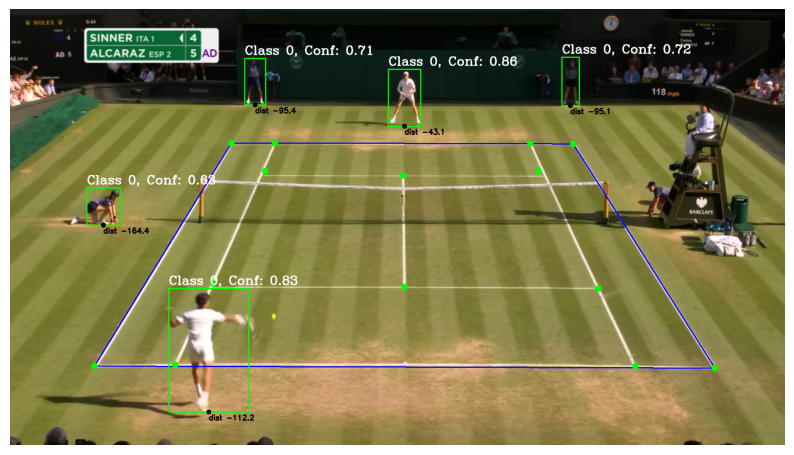

In [12]:
plot_img(feet_img, size=(10, 8))

## Bounding Box Using the Center

In [13]:
body_img = tennis.copy()
for result in out:
    boxes = result.boxes  

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  
        conf = box.conf[0]  
        cls = int(box.cls[0])  

        cv.rectangle(body_img, (x1, y1), (x2, y2), (0, 255, 0), 2)  
        label = f"Class {cls}, Conf: {conf:.2f}"
        cv.putText(body_img, label, (x1, y1 - 10), cv.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255), 2)

        cx, cy = int((x1+x2) / 2), int((y1+y2) / 2)
        player_point = (cx, cy)

        inside = cv.pointPolygonTest(hull, player_point, False)
        dist   = cv.pointPolygonTest(hull, player_point, True)

        if inside >= 0: #in the hall
            color = (0, 255, 0) 
            status = "inside"
        else: #out of the hall
            color = (0, 0, 0) 
            status = f"dist {dist:.1f}"

        cv.circle(body_img, player_point, 6, color, -1)
        cv.putText(body_img, status, (cx, cy + 20), cv.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    

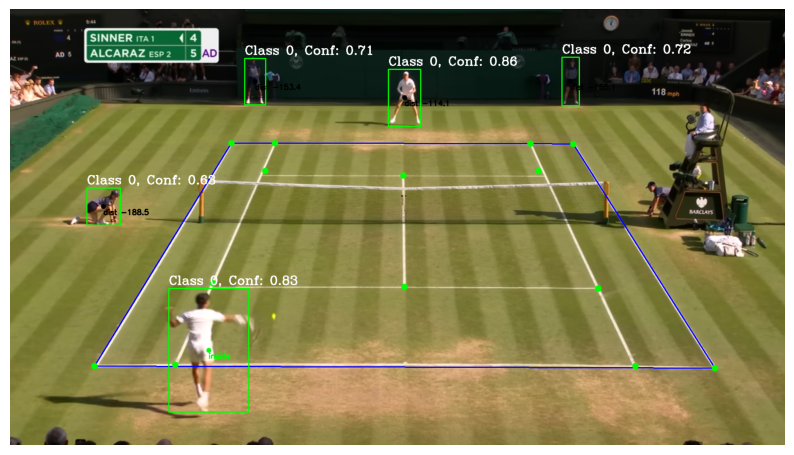

In [14]:
plot_img(body_img, size=(10, 8))

## Filter Using Both (Feet and Body) From the Hall

In this i only wanna show the bboxes that are close to a max distance

In [15]:
max_dist = 70
img__filter = tennis.copy()

for result in out:
    boxes = result.boxes  

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  
        conf = box.conf[0]  
        cls = int(box.cls[0])  

        feet_cx, feet_cy = int((x1 + x2) / 2), int(y2) #feet
        body_cx, body_cy = int((x1+x2) / 2), int((y1+y2) / 2) #center of body
        feet_point = (feet_cx, feet_cy)
        body_point = (body_cx, body_cy)

        #hull distance
        feet_inside = cv.pointPolygonTest(hull, feet_point, False)
        feet_dist   = cv.pointPolygonTest(hull, feet_point, True)

        body_inside = cv.pointPolygonTest(hull, body_point, False)
        body_dist   = cv.pointPolygonTest(hull, body_point, True)

        #if the player is inside or in a number max of pixels
        if feet_inside >= 0:
            ref_point = feet_point
            status = "inside"
            min_dist = 0
        elif body_inside >= 0:
            ref_point = body_point
            status = "inside"
            min_dist = 0
        else: #out of the hall
            if abs(feet_dist) <= abs(body_dist):
                ref_point = feet_point
                min_dist = abs(feet_dist)
            else:
                ref_point = body_point
                min_dist = abs(body_dist)
            if min_dist > max_dist:
                continue
            status = f"dist {min_dist:.1f}"

        cv.rectangle(img__filter, (x1, y1), (x2, y2), (0, 255, 0), 2)  
        label = f"Class {cls}, Conf: {conf:.2f}"
        cv.putText(img__filter, label, (x1, y1 - 10), cv.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255), 2)

        cv.circle(img__filter, ref_point, 6, (0, 255, 0), -1)
        cv.putText(img__filter, status, (ref_point[0], ref_point[1] + 20),cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            

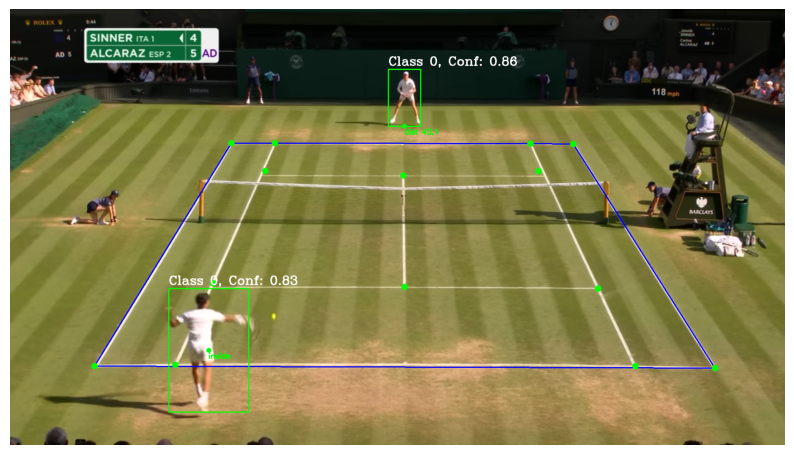

In [16]:
plot_img(img__filter, size=(10, 8))

https://github.com/Malk97sc/Images/blob/main/Keypoints/detect_players.ipynb